<a href="https://colab.research.google.com/github/Flurbs222/NumericalAnalysis-Projects/blob/main/Project_2-Interpolation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Team Project 2 - Interpolation

In this project, we investigate various aspects of polynomial interpolation and spline interpolation.

There are several essential NumPy routines.
<ul>
    <li><a href="https://docs.scipy.org/doc/numpy-1.13.0/reference/routines.polynomials.classes.html">Polynomial</a> routine enables identifying a vector $[a, b, c, \cdots]$ with a polynomial $a + bx + cx^2+ \cdots$ and manipulating it;</li>
    <li><a href="https://docs.scipy.org/doc/numpy-1.13.0/reference/routines.linalg.html">Linear algebra</a> routine could be used to do some basic linear algebra;</li>
    <li><a href="https://matplotlib.org/users/pyplot_tutorial.html">Pyplot</a> is used to plot graphs.</li>
</ul>

You may find some information and examples by clicking the name of each routine. Also, check the Python tutorial that I posted on Blackboard, at the beginning of this semester.

For the first three problems, $f(x) = \frac{1}{1+x^2}$. We will compute several approximations of $f(x)$ on $[-5, 5]$, coming from various interpolations of sample points on the graph of $f(x)$.

1. (10 pts) Let $\mathrm{sample} = [x_0, x_1, \cdots, x_n]$ be a list of (not necessarily equally spaced) numbers such that $x_j < x_{j+1}$. Construct a python function **Lagrange(sample)** that calculates the polynomial interpolation $p_n(x)$ of $\{(x_0, f(x_0)), (x_1, f(x_1)), \cdots, (x_n, f(x_n))\}$ on $[x_0, x_n]$ using <em>Lagrange interpolation</em>.

Using this, find the polynomial interpolation $p_{9}(x)$ of $\{(x_0, f(x_0)), (x_1, f(x_1)), \cdots, (x_9, f(x_9))\}$ of degree $\le 9$ with:

(a) evenly spaced sample points $x_0 = -5, x_1, x_2, \cdots, x_9 = 5$,

(b) $x_0 = 5\cos(\frac{19}{20}\pi), x_1 = 5\cos(\frac{17}{20}\pi), x_2 = 5\cos(\frac{15}{20}\pi), \cdots, x_9 = 5\cos(\frac{1}{20}\pi)$,

and sketch the graph of $f(x)$ and $p_{9}(x)$ with these two sets of sample points on the same plane (for $-5 \le x \le 5$).

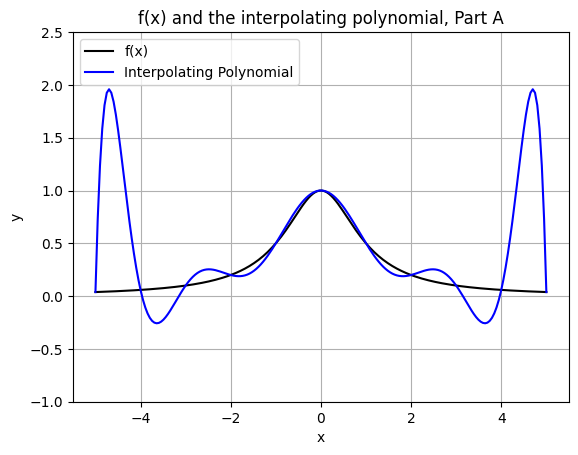

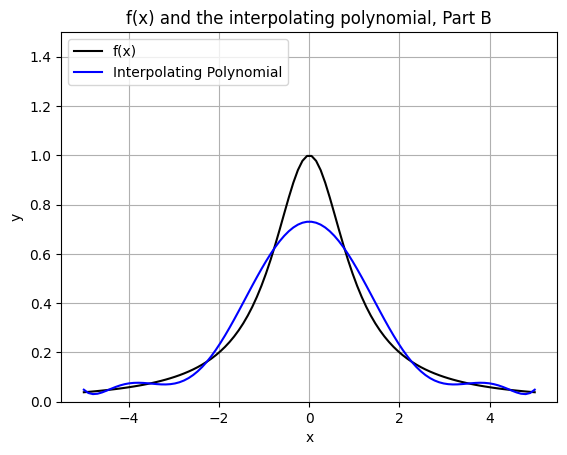

In [ ]:
import math
import numpy as np
import numpy.polynomial as poly
import matplotlib.pyplot as plt

f = lambda x: 1/(1+x**2)

def Lagrange(sample):

  def L(i):
    l = poly.Polynomial([1.0])
    for j in range(len(sample)):
      if i == j:
        continue
      else:
        l = l * poly.Polynomial([-sample[j]/(sample[i]-sample[j]),1/(sample[i]-sample[j])])
    return l

  interpolating = poly.Polynomial([0])

  for i in range(len(sample)):
    interpolating = interpolating + f(sample[i])*L(i)
  return interpolating



#A
x_i = [i for i in range(-5,6)]
y_i = [f(x) for x in x_i]

#Graph of function:

x_values = np.linspace(-5,5,200)
y_values = [f(x) for x in x_values]

plt.plot(x_values,y_values, label ='f(x)', color='black')

p=Lagrange(x_i)

polynomial_values = p(x_values)

plt.plot(x_values, polynomial_values, label='Interpolating Polynomial', color='blue')

params = {'mathtext.default': 'regular' }
plt.rcParams.update(params)
#for i,x in enumerate(x_i):
 # plt.annotate(f"($x_{i}$, f($x_{i}$))",(x,f(x)))
plt.xlabel('x')
plt.ylabel('y')
plt.title('f(x) and the interpolating polynomial, Part A')
plt.grid(True)
plt.legend(loc="upper left")
plt.ylim(-1, 2.5)

plt.show()


#B
plt.clf()

x_i = [5*math.cos(i/20*math.pi) for i in range(19,-1,-2)]
y_i = [f(x) for x in x_i]

#Graph of function:

x_values = np.linspace(-5,5,100)
y_values = [f(x) for x in x_values]

plt.plot(x_values,y_values, label ='f(x)', color='black')

p=Lagrange(x_i)

polynomial_values = p(x_values)

plt.plot(x_values, polynomial_values, label='Interpolating Polynomial', color='blue')

params = {'mathtext.default': 'regular' }
plt.rcParams.update(params)
#for i,x in enumerate(x_i):
 # plt.annotate(f"($x_{i}$, f($x_{i}$))",(x,f(x)))
plt.xlabel('x')
plt.ylabel('y')
plt.title('f(x) and the interpolating polynomial, Part B')
plt.grid(True)
plt.legend(loc="upper left")
plt.ylim(0, 1.5)

plt.show()



2. (10 pts) Let $\mathrm{sample} = [x_0, x_1, \cdots, x_n]$ be a list of (not necessarily equally spaced) numbers such that $x_j < x_{j+1}$. Construct a python function **DivDiff(sample)** that calcuates the polynomial interpolation $p_n(x)$ of $\{(x_0, f(x_0)), (x_1, f(x_1)), \cdots, (x_n, f(x_n))\}$ using <em>divided differences</em>.

Using this, find the polynomial interpolation $p_{9}(x)$ of $\{(x_0, f(x_0)), (x_1, f(x_1)), \cdots, (x_9, f(x_9))\}$ of degree $\le 9$ with:

(a) evenly spaced sample points $x_0 = -5, x_1, x_2, \cdots, x_9 = 5$,

(b) $x_0 = 5\cos(\frac{19}{20}\pi), x_1 = 5\cos(\frac{17}{20}\pi), x_2 = 5\cos(\frac{15}{20}\pi), \cdots, x_9 = 5\cos(\frac{1}{20}\pi)$,

and sketch the graph of $f(x)$ and $p_{9}(x)$ with these two sets of sample points on the same plane (for $-5 \le x \le 5$).

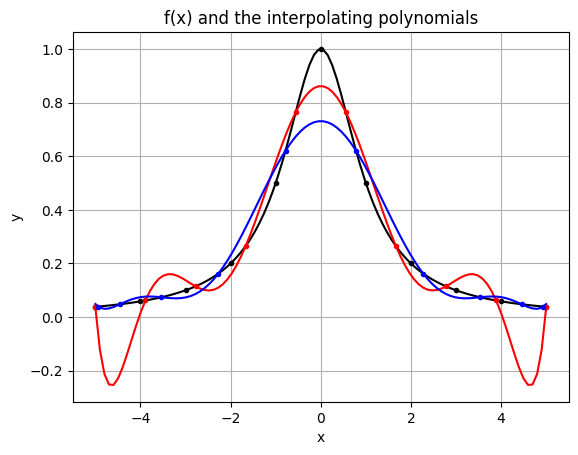

In [ ]:
import math
import numpy as np
from numpy.polynomial import Polynomial as Poly
import matplotlib.pyplot as plt

def f(x):
    return 1 / (1 + x**2)

def DivDiff(sample):
    n = len(sample)

    y = [f(sample[i]) for i in range(n)]

    def divided_difference(k_th, start, end):
        if start == end:
            return y[start]
        return (divided_difference(k_th - 1, start + 1, end) - divided_difference(k_th - 1, start, end - 1)) / (sample[end] - sample[start])


    def polynomial(x):
        p = divided_difference(0, 0, 0)
        for i in range(1, n):
            nth_term = divided_difference(i, 0, i)
            for j in range(i):
                nth_term *= (x - sample[j])
            p += nth_term
        return p

    return polynomial
sample_a=[-5+i*10/9 for i in range(10)]
sample_b=[5*math.cos((19-2*i)*math.pi/20) for i in range(10)]
p_a = DivDiff(sample_a)
p_b = DivDiff(sample_b)

x_values = np.linspace(-5,5,100)
y_values = [f(x) for x in x_values]

plt.plot(x_values,y_values, color='black')
plt.plot(x_values,[p_a(x) for x in x_values], color='red')
plt.plot(x_values,[p_b(x) for x in x_values], color='blue')

x_sample = [i for i in range (-5,6)]
y_sample = [f(x) for x in x_sample]


plt.plot(x_sample,y_sample, '.',color="black")
plt.plot(sample_a, [p_a(x) for x in sample_a], '.',color='red')
plt.plot(sample_b, [p_b(x) for x in sample_b], '.',color='blue')


plt.xlabel('x')
plt.ylabel('y')
plt.title('f(x) and the interpolating polynomials')
plt.grid(True)


plt.show()



3. (10 pts) Let $\mathrm{sample} = [x_0, x_1, \cdots, x_n]$ be a list of (not necessarily equally spaced) numbers such that $x_j < x_{j+1}$. Construct a python function **CubicSpline(sample)** that calcuates the natural cubic spline function $S(x)$ with the sample points $\{(x_0, f(x_0)), (x_1, f(x_1)), \cdots, (x_n, f(x_n))\}$.

Using this, find the natural cubic spline function $S(x)$ with:

(a) evenly spaced sample points $x_0 = -5, x_1, x_2, \cdots, x_9 = 5$,

(b) $x_0 = 5\cos(\frac{19}{20}\pi), x_1 = 5\cos(\frac{17}{20}\pi), x_2 = 5\cos(\frac{15}{20}\pi), \cdots, x_9 = 5\cos(\frac{1}{20}\pi)$,

and sketch the graph of $f(x)$ and $S(x)$ with these two sets of sample points on the same plane (for $-5 \le x \le 5$).

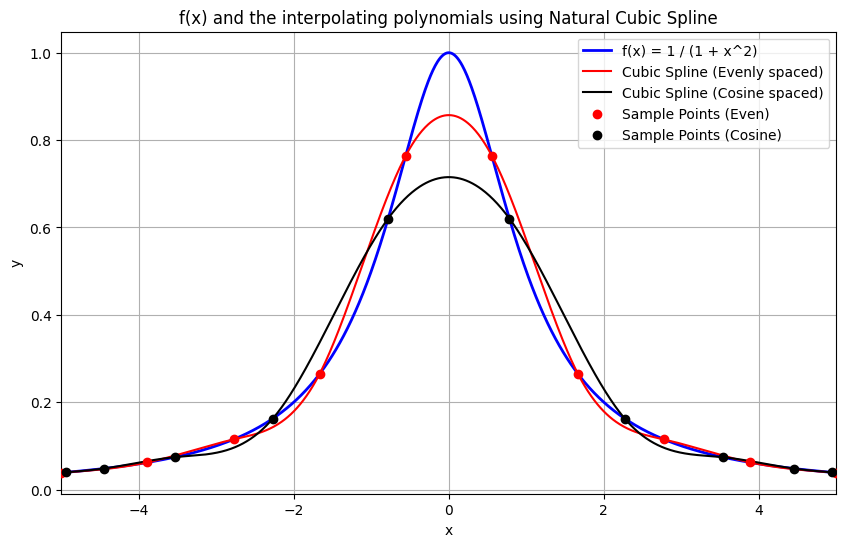

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return 1 / (1 + x**2)

def CubicSpline(sample):
    x = np.array(sample)
    y = f(x)
    n = len(x)

    h = np.diff(x)
    b = np.diff(y) / h

    # Second derivatives
    A = np.zeros((n, n))
    rhs = np.zeros(n)

    A[0, 0] = 1
    A[-1, -1] = 1
    rhs[0] = rhs[-1] = 0  # Second derivative is 0 at the ends

    # Fill the matrix
    for i in range(1, n - 1):
        A[i, i - 1] = h[i - 1]
        A[i, i] = 2 * (h[i - 1] + h[i])
        A[i, i + 1] = h[i]
        rhs[i] = 3 * (b[i] - b[i - 1])

    m = np.linalg.solve(A, rhs)

    # Cubic spline coefficients
    coeffs = []
    for i in range(n - 1):
        a = y[i]
        b = (y[i + 1] - y[i]) / h[i] - h[i] * (2 * m[i] + m[i + 1]) / 3
        c = m[i]
        d = (m[i + 1] - m[i]) / (3 * h[i])
        coeffs.append((a, b, c, d))

    # Function to evaluate the S(n)
    def S(x_val):
        for i in range(n - 1):
            if x[i] <= x_val <= x[i + 1]:
                a, b, c, d = coeffs[i]
                dx = x_val - x[i]
                return a + b * dx + c * dx**2 + d * dx**3
        return None  # If x is outside the domain

    return S

# (a) sample points
x_even = np.linspace(-5, 5, 10)
spline_even = CubicSpline(x_even)

# (b) sample points
x_cos = 5 * np.cos(np.pi * np.linspace(19, 1, 10) / 20)
spline_cos = CubicSpline(x_cos)

# Generate x values
x_plot = np.linspace(-5, 5, 1000)

# Calculate f(x) and S(x)
y_f = f(x_plot)
y_spline_even = [spline_even(x) for x in x_plot]
y_spline_cos = [spline_cos(x) for x in x_plot]

# Plot
plt.figure(figsize=(10, 6))

plt.plot(x_plot, y_f, label="f(x) = 1 / (1 + x^2)", color='blue', linewidth=2)
plt.plot(x_plot, y_spline_even, label="Cubic Spline (Evenly spaced)", color='red')

plt.plot(x_plot, y_spline_cos, label="Cubic Spline (Cosine spaced)", color='black')

plt.scatter(x_even, f(x_even), color='red', zorder=5, label="Sample Points (Even)")
plt.scatter(x_cos, f(x_cos), color='black', zorder=5, label="Sample Points (Cosine)")

plt.xlim(-5, 5)

plt.title("f(x) and the interpolating polynomials using Natural Cubic Spline")
plt.xlabel("x")
plt.ylabel("y")

plt.legend()
plt.grid(True)

plt.show()

4. (20 pts) In computer graphics, <b>vectorization</b> is the conversion of raster graphics into vector graphics.

Roughly, raster graphics is a graphic format that consists of a collection of colored dots. Examples include JPG, GIF, and PNG formats. Raster graphics are resolution dependent, meaning they cannot scale up to an arbitrary resolution without loss of apparent quality. (If you zoom in a jpg file, then you can see many colored squares.)

On the other hand, vector graphics are defined in terms of points connected by lines and curves to form polygons and other shapes. Typical examples are font files, SVG, and PDF. Because they encode relevant mathematical data, it could be easily scaled up without any loss of quality.

Vectorization or image tracing is a method to convert a given raster graphic data into a vector graphic format. This project will investigate one of the simplest kinds of image tracing by using the spline function. Consider the following image of a turtle:

![turtle.jpg](https://drive.google.com/uc?id=1oOa6agPnBA4hcGsa9nDJ8QXp4I9yeL-U)

What you need to do is trace the contour of the upper part of the turtle's body by using natural cubic spline functions. More precisely, you should calculate a natural cubic spline function $S(x)$ that describes the upper outline of the turtle, starting from the left end of its shell to the rightmost point to its eye.

<ol>
    <li>By using some graphic tool such as Microsoft Paint or Photoshop, find the coordinates of several sample points.</li>
    <li>Compute the natural cubic spline function connecting the sample points.</li>
    <li>Plot your spline function over the image. </li>
</ol>

Your graph of the spline function should have no significant error (I know this is somewhat subjective, but...) compared to the outline of the original image. 10 pts for the correctness of the code. The remaining 10 points are for the best performance, in terms of the <em>number of sample points</em>. For example, the team using the smallest number of sample points will get 10 pts, the next team will get 9 pts, etc. Keep in mind that your spline should not have any significant difference from the original image. It is important which sample points you use. Try several examples and get some lessons.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Overlay the image onto the plot
image = mpimg.imread('download.jpg')
fig, ax = plt.subplots()
ax.imshow(image)

# Customize the plot
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_title('Image with Overlayed Plot')
ax.legend()
ax.axis('off')

def CubicSpline(x, y):
    x = np.array(x)
    y = np.array(y)
    n = len(x)

    # Compute differences
    h = np.diff(x)
    b = np.diff(y) / h

    # Set up the tridiagonal system for second derivatives
    A = np.zeros((n, n))
    rhs = np.zeros(n)

    # Natural spline boundary conditions (second derivative = 0 at ends)
    A[0, 0] = 1
    A[-1, -1] = 1
    rhs[0] = rhs[-1] = 0

    # Fill the matrix for interior points
    for i in range(1, n - 1):
        A[i, i - 1] = h[i - 1]
        A[i, i] = 2 * (h[i - 1] + h[i])
        A[i, i + 1] = h[i]
        rhs[i] = 3 * (b[i] - b[i - 1])

    # Solve for second derivatives
    m = np.linalg.solve(A, rhs)

    # Compute cubic coefficients for each segment
    coeffs = []
    for i in range(n - 1):
        a = y[i]
        b = (y[i + 1] - y[i]) / h[i] - h[i] * (2 * m[i] + m[i + 1]) / 3
        c = m[i]
        d = (m[i + 1] - m[i]) / (3 * h[i])
        coeffs.append((a, b, c, d))

    # Function to evaluate the spline at a given x_val
    def S(x_val):
        for i in range(n - 1):
            if x[i] <= x_val <= x[i + 1]:
                a, b, c, d = coeffs[i]
                dx = x_val - x[i]
                return a + b * dx + c * dx**2 + d * dx**3
        raise ValueError(f"x_val {x_val} is outside the spline domain [{x[0]}, {x[-1]}]")

    return S


x = [243, 308, 417, 745, 991, 1213, 1250, 1307,1419, 1488]
y = [654, 622, 529, 353, 294, 329, 343,  300, 266, 271]
# Create spline function
spline_x = CubicSpline(x, y)

# Evaluate spline at original x points for plotting
x_eval = np.linspace(min(x), max(x), 500)
y_eval = [spline_x(i) for i in x_eval]

# Plot
plt.plot(x, y, 'o', label="Data Points", markersize = 5,color = 'yellow')
plt.plot(x_eval, y_eval, label="Cubic Spline", color='red', lw=2)
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Cubic Spline Approximation")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'download.jpg'

1. Great work! (10 pts)

2. Very nice. (10 pts)

3. Excellent job. (10 pts)

4. You did a very nice job. The number of samples you used are the second from the last (+7 pts). But the error is reasonably small. (+1 pt) However, there is a runtime error (related to downloading the image), so I can't run the code (-3 pts). (10 + 7 + 1 - 3 = 15 pts)

(10 + 10 + 10 + 15 = 45 pts)